## Import

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [2]:
import sys
import torch

print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch file:", torch.__file__)

Python exe: /usr/bin/python3
Torch version: 2.11.0+cu128
Torch file: /usr/local/lib/python3.12/dist-packages/torch/__init__.py


## Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

root = "/content/drive/MyDrive/datasets"

Mounted at /content/drive


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(
    root=root,
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=root,
    train=False,
    download=False,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

## Model

In [ ]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 10)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]


## Evaluation

In [10]:
def evaluate_model(model, device, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for data, target in test_loader:

            data = data.to(device)
            target = target.to(device)

            output = model(data)

            pred = output.argmax(dim=1)

            correct += (pred == target).sum().item()
            total += target.size(0)

    acc = 100 * correct / total

    print(f"Accuracy = {acc:.2f}%")

    return acc

## Baseline Training

In [ ]:
def fine_tune_clean(
    model,
    device,
    train_loader,
    test_loader,
    optimizer,
    criterion,
    epochs=5
):

    for epoch in range(epochs):

        model.train()

        for data, target in train_loader:

            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = model(data)

            loss = criterion(output, target)

            loss.backward()

            optimizer.step()

        print(f"\nEpoch {epoch+1}")
        evaluate_model(model, device, test_loader)

## Train Baseline

In [ ]:
fine_tune_clean(
    model,
    device,
    train_loader,
    test_loader,
    optimizer,
    criterion,
    epochs=5
)


Epoch 1
Accuracy = 95.22%

Epoch 2
Accuracy = 95.88%

Epoch 3
Accuracy = 96.31%

Epoch 4
Accuracy = 96.29%

Epoch 5
Accuracy = 96.61%


## Save Baseline

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/models/efficientnet_clean.pth"
)

## FGSM Attack

In [15]:
def fgsm_attack(image, epsilon, data_grad):

    sign_data_grad = data_grad.sign()

    perturbed_image = image + epsilon * sign_data_grad

    perturbed_image = torch.clamp(
        perturbed_image,
        0,
        1
    )

    return perturbed_image

## FGSM Evaluation

In [13]:
def test_attack(
    model,
    device,
    test_loader,
    epsilon
):

    correct = 0
    total = 0

    model.eval()

    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        data.requires_grad = True

        output = model(data)

        loss = criterion(output, target)

        model.zero_grad()
        loss.backward()

        data_grad = data.grad.data

        adv_data = fgsm_attack(
            data,
            epsilon,
            data_grad
        )

        output = model(adv_data)

        final_pred = output.argmax(dim=1)

        correct += (final_pred == target).sum().item()
        total += target.size(0)

    acc = 100 * correct / total

    print(
        f"Epsilon={epsilon} "
        f"Accuracy={acc:.2f}%"
    )

    return acc

## Baseline Robustness

In [ ]:
epsilons = [
    0,
    2/255,
    4/255,
    8/255
]

baseline_acc = []

for eps in epsilons:

    acc = test_attack(
        model,
        device,
        test_loader,
        eps
    )

    baseline_acc.append(acc)

Epsilon=0 Accuracy=96.61%
Epsilon=0.00784313725490196 Accuracy=12.05%
Epsilon=0.01568627450980392 Accuracy=10.53%
Epsilon=0.03137254901960784 Accuracy=10.27%


## Adversarial Training

In [ ]:
def adversarial_training(
    model,
    train_loader,
    optimizer,
    criterion,
    device,
    epochs=5,
    epsilon=8/255
):

    for epoch in range(epochs):

        model.train()

        for data, target in train_loader:

            data = data.to(device)
            target = target.to(device)

            data.requires_grad = True

            output = model(data)

            loss = criterion(output, target)

            model.zero_grad()

            loss.backward()

            data_grad = data.grad.data

            adv_data = fgsm_attack(
                data,
                epsilon,
                data_grad
            )

            optimizer.zero_grad()

            clean_output = model(data)
            clean_loss = criterion(
                clean_output,
                target
            )

            adv_output = model(adv_data)
            adv_loss = criterion(
                adv_output,
                target
            )

            total_loss = (
                0.7 * clean_loss
                + 0.3 * adv_loss
            )

            total_loss.backward()

            optimizer.step()

        print(
            f"Adversarial Epoch {epoch+1}"
        )

## Run Adversarial Training

In [ ]:
adversarial_training(
    model,
    train_loader,
    optimizer,
    criterion,
    device,
    epochs=5,
    epsilon=8/255
)

Adversarial Epoch 1
Adversarial Epoch 2
Adversarial Epoch 3
Adversarial Epoch 4
Adversarial Epoch 5


## Save Robust Model

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/models/efficientnet_fgsm_at.pth"
)

## Robustness After Defense

In [16]:
robust_acc = []

for eps in epsilons:

    acc = test_attack(
        model,
        device,
        test_loader,
        eps
    )

    robust_acc.append(acc)

Epsilon=0 Accuracy=66.29%
Epsilon=0.00784313725490196 Accuracy=89.36%
Epsilon=0.01568627450980392 Accuracy=88.87%
Epsilon=0.03137254901960784 Accuracy=80.41%


## Plot

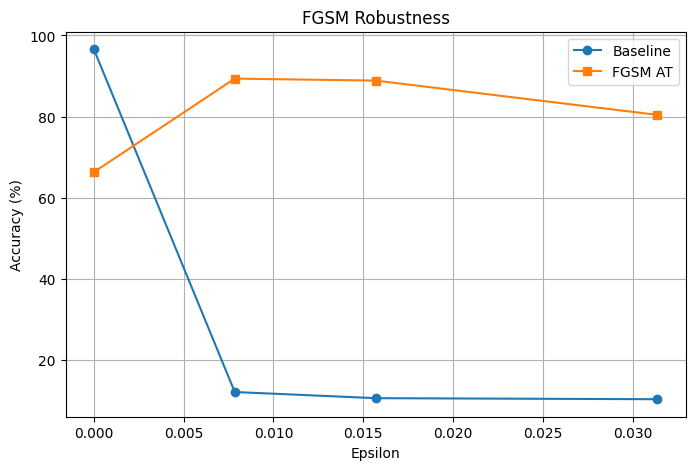

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    epsilons,
    baseline_acc,
    'o-',
    label='Baseline'
)

plt.plot(
    epsilons,
    robust_acc,
    's-',
    label='FGSM AT'
)

plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.title("FGSM Robustness")

plt.legend()

plt.grid()

plt.show()